# Customer Segmentation (Online Retail)
Groups ~4.3k retail customers into segments using RFM-style behaviour features and clustering.

**Step 1: Load data.** Read `Online Retail.xlsx` (541,909 transactions) from the UCI zip.

In [2]:
# LOAD DATASET AND INSPECT STRUCTURE

import zipfile
import pandas as pd
import os

extract_dir = "data/online_retail"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile("online+retail.zip", "r") as z:
    z.extractall(extract_dir)

excel_path = os.path.join(extract_dir, "Online Retail.xlsx")
df = pd.read_excel(excel_path, engine="openpyxl")

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nDataset information:")
df.info()
print("\nStatistical summary:")
display(df.describe(include="all").T)

DATASET LOADED SUCCESSFULLY
Shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Statistical summary:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Step 2: EDA.** Check missing values, duplicates, cancellations, negative quantities/prices, top countries and products. Why: ~25% of rows have no `CustomerID` and there are returns, so cleaning is needed.

DATASET OVERVIEW
Rows: 541909
Columns: 8
Duplicate rows: 5268

MISSING VALUES
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

MISSING VALUE PERCENTAGES
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

UNIQUE VALUES
InvoiceNo: 25900
StockCode: 4070
Description: 4223
Quantity: 722
InvoiceDate: 23260
UnitPrice: 1630
CustomerID: 4372
Country: 38

QUANTITY STATISTICS
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

UNIT PRICE STATISTICS
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%  

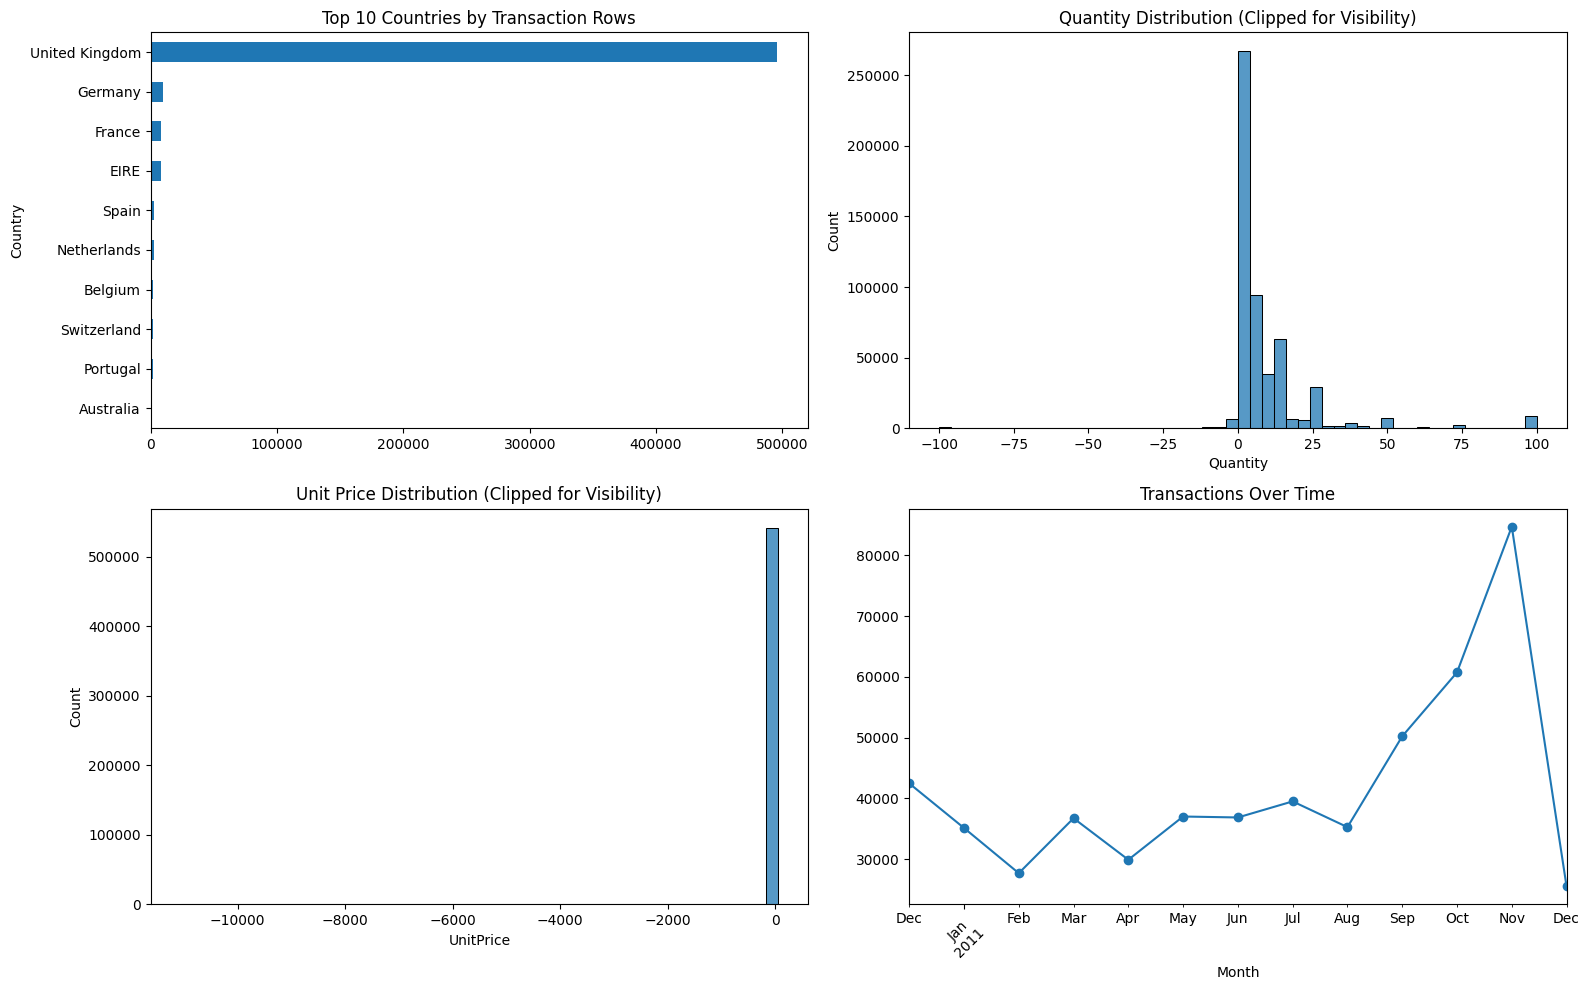

In [3]:
# EXPLORATORY DATA ANALYSIS (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

print("\nMISSING VALUES")
print(df.isnull().sum())
print("\nMISSING VALUE PERCENTAGES")
print((df.isnull().mean() * 100).round(2))

print("\nUNIQUE VALUES")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

print("\nQUANTITY STATISTICS")
print(df["Quantity"].describe())

print("\nUNIT PRICE STATISTICS")
print(df["UnitPrice"].describe())

print("\nTRANSACTION ANALYSIS")
print("Unique invoices:", df["InvoiceNo"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique customers:", df["CustomerID"].nunique())
print("Countries:", df["Country"].nunique())
print("Cancelled invoices:", df["InvoiceNo"].astype(str).str.startswith("C").sum())
print("Negative quantity rows:", (df["Quantity"] < 0).sum())
print("Zero or negative prices:", (df["UnitPrice"] <= 0).sum())

print("\nTOP 10 COUNTRIES")
print(df["Country"].value_counts().head(10))

print("\nTOP 10 PRODUCTS")
print(df["Description"].value_counts().head(10))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df["Country"].value_counts().head(10).sort_values().plot(
    kind="barh", ax=axes[0, 0], title="Top 10 Countries by Transaction Rows"
)

sns.histplot(df["Quantity"].clip(-100, 100), bins=50, ax=axes[0, 1])
axes[0, 1].set_title("Quantity Distribution (Clipped for Visibility)")

sns.histplot(df["UnitPrice"].clip(upper=50), bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Unit Price Distribution (Clipped for Visibility)")

df["InvoiceDate"].dt.to_period("M").value_counts().sort_index().plot(
    ax=axes[1, 1], marker="o"
)
axes[1, 1].set_title("Transactions Over Time")
axes[1, 1].set_xlabel("Month")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Step 3: Cleaning.** Drop duplicates, rows without customer/description, cancelled invoices, and non-positive quantity/price. Add `Revenue`. Result: 392,692 rows, 4,338 customers.

In [4]:
# DATA CLEANING

df_clean = df.copy()

print("=" * 60)
print("BEFORE CLEANING")
print("=" * 60)
print("Shape:", df_clean.shape)
print("Duplicates:", df_clean.duplicated().sum())
print("Missing CustomerID:", df_clean["CustomerID"].isna().sum())

before_rows = len(df_clean)

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Remove rows without customer IDs or product descriptions
df_clean = df_clean.dropna(subset=["CustomerID", "Description"])

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep valid purchase quantities and prices
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

# Correct data types
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Create transaction revenue
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("\n" + "=" * 60)
print("AFTER CLEANING")
print("=" * 60)
print("Original rows:", before_rows)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", before_rows - len(df_clean))
print("Remaining duplicates:", df_clean.duplicated().sum())
print("Missing values:\n", df_clean.isnull().sum())
print("Invalid quantities:", (df_clean["Quantity"] <= 0).sum())
print("Invalid prices:", (df_clean["UnitPrice"] <= 0).sum())
print("Unique customers:", df_clean["CustomerID"].nunique())
print("Unique products:", df_clean["StockCode"].nunique())
print("Unique invoices:", df_clean["InvoiceNo"].nunique())
print("Total revenue: £{:,.2f}".format(df_clean["Revenue"].sum()))

display(df_clean.head())

BEFORE CLEANING
Shape: (541909, 8)
Duplicates: 5268
Missing CustomerID: 135080

AFTER CLEANING
Original rows: 541909
Cleaned shape: (392692, 9)
Rows removed: 149217
Remaining duplicates: 0
Missing values:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64
Invalid quantities: 0
Invalid prices: 0
Unique customers: 4338
Unique products: 3665
Unique invoices: 18532
Total revenue: £8,887,208.89


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


**Step 4: Feature engineering.** Build one row per customer: Recency, Frequency, Monetary, plus quantity, unique products, tenure and average order value. Why: clustering needs customer-level behaviour, not transactions.

CUSTOMER FEATURE ENGINEERING
Customers: 4338
Features: 10

RFM STATISTICS


,count,mean,min,25%,50%,75%,max,std
CustomerID,4338.0,15300.41,12346.0,13813.25,15299.5,16778.75,18287.0,1721.81
Recency,4338.0,92.54,1.0,18.0,51.0,142.0,374.0,100.01
Frequency,4338.0,4.27,1.0,1.0,2.0,5.0,209.0,7.7
Monetary,4338.0,2048.69,3.75,306.48,668.57,1660.6,280206.02,8985.23
TotalQuantity,4338.0,1187.64,1.0,159.0,378.0,989.75,196915.0,5043.62
UniqueProducts,4338.0,61.5,1.0,16.0,35.0,77.0,1787.0,85.37
FirstPurchase,4338,2011-04-30 17:06:50.857538048,2010-12-01 08:26:00,2011-01-17 11:13:15,2011-04-05 09:52:30,2011-08-19 10:11:30,2011-12-09 12:16:00,NaN
LastPurchase,4338,2011-09-08 11:38:59.045643008,2010-12-01 09:53:00,2011-07-20 19:18:00,2011-10-20 10:40:30,2011-11-22 11:05:45,2011-12-09 12:50:00,NaN
CustomerTenureDays,4338.0,130.45,0.0,0.0,92.5,251.75,373.0,132.04
AverageOrderValue,4338.0,417.65,3.45,177.87,291.94,428.28,84236.25,1796.51



CUSTOMER FEATURES SAMPLE


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,FirstPurchase,LastPurchase,CustomerTenureDays,AverageOrderValue
0,12346,326,1,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,0,77183.600000
1,12347,2,7,4310.00,2458,103,2010-12-07 14:57:00,2011-12-07 15:52:00,365,615.714286
2,12348,75,4,1797.24,2341,22,2010-12-16 19:09:00,2011-09-25 13:13:00,282,449.310000
3,12349,19,1,1757.55,631,73,2011-11-21 09:51:00,2011-11-21 09:51:00,0,1757.550000
4,12350,310,1,334.40,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,0,334.400000



CORRELATION MATRIX


,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,CustomerTenureDays,AverageOrderValue
Recency,1.00,-0.26,-0.12,-0.12,-0.30,-0.51,-0.00
Frequency,-0.26,1.00,0.55,0.56,0.69,0.48,0.02
Monetary,-0.12,0.55,1.00,0.92,0.39,0.23,0.39
TotalQuantity,-0.12,0.56,0.92,1.00,0.41,0.23,0.41
UniqueProducts,-0.30,0.69,0.39,0.41,1.00,0.46,0.04
CustomerTenureDays,-0.51,0.48,0.23,0.23,0.46,1.00,0.01
AverageOrderValue,-0.00,0.02,0.39,0.41,0.04,0.01,1.00


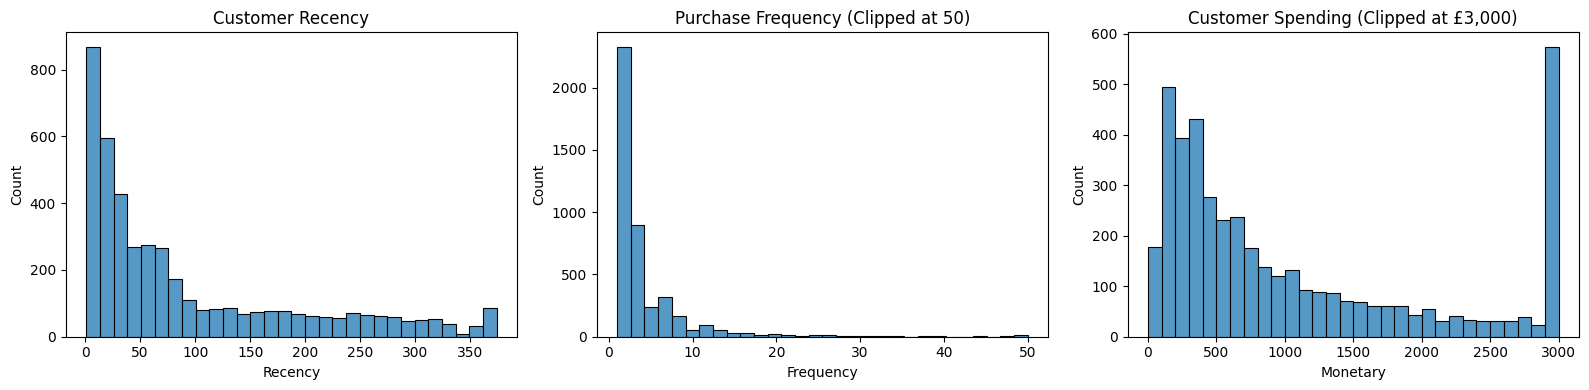

In [5]:
# FEATURE ENGINEERING: CUSTOMER RFM ANALYSIS

import numpy as np
import pandas as pd

reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max")
).reset_index()

rfm["CustomerTenureDays"] = (
    rfm["LastPurchase"] - rfm["FirstPurchase"]
).dt.days

rfm["AverageOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

rfm.replace([np.inf, -np.inf], np.nan, inplace=True)
rfm.dropna(inplace=True)

print("=" * 60)
print("CUSTOMER FEATURE ENGINEERING")
print("=" * 60)
print("Customers:", len(rfm))
print("Features:", rfm.shape[1])
print("\nRFM STATISTICS")
display(rfm.describe().round(2).T)

print("\nCUSTOMER FEATURES SAMPLE")
display(rfm.head())

print("\nCORRELATION MATRIX")
display(rfm.drop(columns=["CustomerID", "FirstPurchase", "LastPurchase"])
         .corr(numeric_only=True).round(2))

# VISUALIZE CUSTOMER BEHAVIOR

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Customer Recency")

sns.histplot(rfm["Frequency"].clip(upper=50), bins=30, ax=axes[1])
axes[1].set_title("Purchase Frequency (Clipped at 50)")

sns.histplot(rfm["Monetary"].clip(upper=3000), bins=30, ax=axes[2])
axes[2].set_title("Customer Spending (Clipped at £3,000)")

plt.tight_layout()
plt.show()

**Step 5: Scale + pick k.** Log-transform (spending is heavily skewed) and standardise, then test k=2 to 8 with elbow, silhouette and Davies-Bouldin. k=2 scores best on both metrics.

FEATURE SCALING COMPLETE
Customer samples: 4338
Features: 7
Missing values: 0


,Clusters,Inertia,Silhouette Score,Davies-Bouldin Score
0,2,17207.2368,0.3547,1.0444
1,3,13837.0402,0.2750,1.2467
2,4,11635.0920,0.2646,1.2117
3,5,10398.6955,0.2440,1.3021
4,6,9540.2888,0.2417,1.2948
5,7,8889.9277,0.2296,1.3034
6,8,8351.3419,0.2227,1.3218


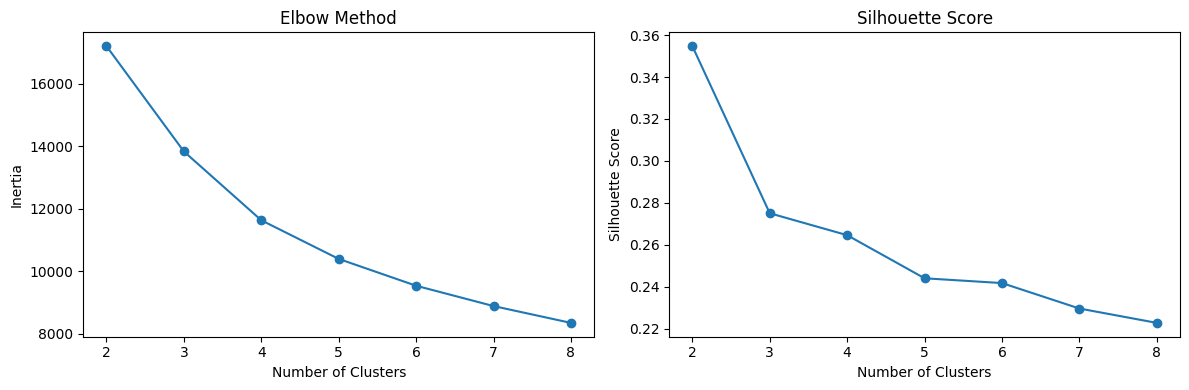

SCALING AND CLUSTER SELECTION COMPLETE


In [6]:
# FEATURE SCALING AND OPTIMAL CLUSTER SELECTION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "CustomerTenureDays",
    "AverageOrderValue"
]

X = rfm[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# Reduce skewness in positive-valued customer features
X_log = np.log1p(X.clip(lower=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("FEATURE SCALING COMPLETE")
print("Customer samples:", X_scaled.shape[0])
print("Features:", X_scaled.shape[1])
print("Missing values:", np.isnan(X_scaled).sum())

# Evaluate different cluster counts
results = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    results.append({
        "Clusters": k,
        "Inertia": model.inertia_,
        "Silhouette Score": silhouette_score(
            X_scaled, labels, sample_size=2000, random_state=42
        ),
        "Davies-Bouldin Score": davies_bouldin_score(X_scaled, labels)
    })

cluster_results = pd.DataFrame(results)
display(cluster_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cluster_results["Clusters"], cluster_results["Inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia")

axes[1].plot(
    cluster_results["Clusters"],
    cluster_results["Silhouette Score"],
    marker="o"
)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

print("SCALING AND CLUSTER SELECTION COMPLETE")

**Step 6: Compare models.** K-Means vs Agglomerative vs Gaussian Mixture at k=2. K-Means wins on silhouette and Davies-Bouldin, and is also the fastest.

In [7]:
# TRAIN AND COMPARE CLUSTERING MODELS

import time
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

models = {
    "K-Means": KMeans(n_clusters=2, random_state=42, n_init=10),
    "Agglomerative Clustering": AgglomerativeClustering(n_clusters=2),
    "Gaussian Mixture": GaussianMixture(
        n_components=2, random_state=42, n_init=3
    )
}

comparison = []
trained_models = {}
cluster_labels = {}

for name, model in models.items():
    start = time.time()

    if name == "Gaussian Mixture":
        labels = model.fit_predict(X_scaled)
    else:
        labels = model.fit_predict(X_scaled)

    elapsed = time.time() - start

    silhouette = silhouette_score(
        X_scaled, labels, sample_size=2000, random_state=42
    )
    db_score = davies_bouldin_score(X_scaled, labels)

    comparison.append({
        "Model": name,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Score": db_score,
        "Training Time (seconds)": round(elapsed, 3)
    })

    trained_models[name] = model
    cluster_labels[name] = labels

comparison_df = pd.DataFrame(comparison).sort_values(
    "Silhouette Score", ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))

best_name = comparison_df.iloc[0]["Model"]
best_model = trained_models[best_name]
best_labels = cluster_labels[best_name]

rfm["Cluster"] = best_labels

print("Selected model:", best_name)
print("Number of clusters:", len(np.unique(best_labels)))
print("\nCUSTOMER DISTRIBUTION")
print(rfm["Cluster"].value_counts().sort_index())

print("\nCLUSTER PROFILES")
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Avg_Order_Value=("AverageOrderValue", "mean"),
    Avg_Unique_Products=("UniqueProducts", "mean")
).round(2)

display(cluster_profile)

print("\nCLUSTERING MODEL COMPARISON COMPLETE")

,Model,Silhouette Score,Davies-Bouldin Score,Training Time (seconds)
0,K-Means,0.3547,1.0444,0.023
1,Agglomerative Clustering,0.3193,1.0958,1.962
2,Gaussian Mixture,0.3014,1.1768,0.408


Selected model: K-Means
Number of clusters: 2

CUSTOMER DISTRIBUTION
Cluster
0    2177
1    2161
Name: count, dtype: int64

CLUSTER PROFILES


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value,Avg_Unique_Products
Cluster,,,,,,
0,2177,41.21,7.07,3724.97,553.01,100.68
1,2161,144.24,1.46,360.00,281.28,22.03



CLUSTERING MODEL COMPARISON COMPLETE


**Step 7: Save + predict.** Save the model, scaler and cluster profiles with joblib, and add a small `predict_customer_segment()` helper for new customers.

In [8]:
# SAVE MODEL AND CREATE CUSTOMER SEGMENTATION PROTOTYPE

import os
import joblib

save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

artifacts = {
    "model": best_model,
    "scaler": scaler,
    "feature_columns": feature_cols,
    "selected_model": best_name,
    "cluster_profiles": cluster_profile
}

model_path = os.path.join(save_dir, "customer_segmentation_model.joblib")
joblib.dump(artifacts, model_path)

# Customer segmentation prototype
def predict_customer_segment(recency, frequency, monetary,
                             total_quantity, unique_products,
                             tenure_days, average_order_value):

    customer = pd.DataFrame([[
        recency, frequency, monetary, total_quantity,
        unique_products, tenure_days, average_order_value
    ]], columns=feature_cols)

    customer_scaled = scaler.transform(
        np.log1p(customer.clip(lower=0))
    )

    cluster = int(best_model.predict(customer_scaled)[0])
    return cluster

print("MODEL SAVED:", model_path)
print("\nPROTOTYPE TEST")
print("Predicted cluster:", predict_customer_segment(
    20, 8, 1500, 400, 30, 180, 187.5
))

# Save cluster assignments and profiles
rfm.to_csv("../results/customer_segments.csv", index=False)
cluster_profile.to_csv("../results/cluster_profiles.csv")


MODEL SAVED: /content/customer_segmentation_project/customer_segmentation_model.joblib

PROTOTYPE TEST
Predicted cluster: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>